In [1]:
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
sns.set_theme(style='whitegrid')

In [26]:
def plot_chart(ds_name, allocation_scheme, seeds, methods, ylimmin=85, ylimmax=100):
    h = hyperparams[ds_name][allocation_scheme]
    method_full = ['FedAvg', f'qFFL_q{h["qFFL"]}', f'PropFair_base{h["PropFair"]}',
                   f'FedMGDA_epsilon{h["FedMGDA"]}', f'FedFV_alpha{h["FedFV"][0]}_tau{h["FedFV"][1]}',
                   'Tche', f'STche_gamma{h["STche"]}',
                   'EPO', 'FERERO', f'ExcessMTL_llr{h["ExcessMTL"]}', f'AdaExcessMTL_llr{h["AdaExcessMTL"]}',
                   f'AFL_llr{h["AFL"]}', f'AFL_new_llr{h["AFL_new"]}', 
                   f'AFLeg_llr{h["AFLeg"]}', f'AFLeg_new_llr{h["AFLeg_new"]}']

    metrics = ['Average Accuracy', 'Agnostic Loss', 'Accuracy Parity']
    data = [[[] for i in range(len(methods))] for _ in range(len(metrics))]

    for i, method in enumerate(method_full):
        for seed in seeds:
            path = f'../output/10seeds/{ds_name}_{allocation_scheme}/seed{seed}/{method}/log.pickle'
            with open(path, 'rb') as file:
                res = pickle.load(file)

            data[0][i].append(res[-1]['test_infer_stats']['mean_acc'] * 100)
            data[1][i].append(np.max(res[-1]['test_infer_stats']['losses']))
            data[2][i].append(np.sqrt(np.var(res[-1]['test_infer_stats']['accuracys']) * 10000))

    fig, axs = plt.subplots(1, 3, figsize=(24, 5))

    for j in range(len(metrics)):
        boxplot = axs[j].boxplot([data[j][i] for i in range(len(method_full))], 
                                 medianprops=dict(color='k'), patch_artist=True, notch=False)
        for patch, method in zip(boxplot['boxes'], methods):
            patch.set_facecolor(colors[method])
    
        # axs[j].set_ylim(ymin=ylimmin, ymax=ylimmax)
        # axs[j].set_xlabel('Methods', fontsize=14)
        axs[j].set_ylabel((r'$\longleftarrow$ ' if j!=0 else '') + metrics[j] + (r' $\longrightarrow$' if j==0 else ''), 
                          fontsize=15)
        axs[j].set_xticks(np.arange(1, len(methods) + 1))  # Boxplot x-ticks start at 1, not 0
        axs[j].set_xticklabels([display_name[method] for method in methods], rotation=45, ha="right", fontsize=15)

    if allocation_scheme == 'rotation':
        allocation_title = 'Rotation'
    if allocation_scheme == 'partial_class_ni2':
        allocation_title = 'Partial_Class_C=2'
    elif allocation_scheme == 'partial_class_ni5':
        allocation_title = 'Partial_Class_C=5'
    fig.suptitle(f'{ds_name} {allocation_title}', fontsize=20)
    plt.tight_layout()
    plt.savefig(f'figures/boxplots/{ds_name}_{allocation_scheme}_boxplots_new.pdf')
    plt.show()

In [3]:
# 10 seeds
hyperparams = {
    'MNIST': {
        'rotation': {
            'AFL': 0.03, 'AFLeg': 0.3, 'AFL_new': 0.03, 'AFLeg_new': 0.1,
            'STche': 0.01, 'qFFL': 0.1, 'FedMGDA': 0.5, 'FedFV': [0.2, 1], 'PropFair': 2.0,
            'ExcessMTL': 1.0, 'AdaExcessMTL': 0.3
        },
        'partial_class_ni2': {
            'AFL': 0.01, 'AFLeg': 0.3, 'AFL_new': 1.0, 'AFLeg_new': 0.3,
            'STche': 0.01, 'qFFL': 0.1, 'FedMGDA': 0.5, 'FedFV': [0.2, 1], 'PropFair': 2.0,
            'ExcessMTL': 1.0, 'AdaExcessMTL': 1.0
        },
        'partial_class_ni5': {
            'AFL': 0.01, 'AFLeg': 0.1, 'AFL_new': 1.0, 'AFLeg_new': 0.03,
            'STche': 0.01, 'qFFL': 0.1, 'FedMGDA': 0.05, 'FedFV': [0.2, 1], 'PropFair': 2.0,
            'ExcessMTL': 1.0, 'AdaExcessMTL': 1.0
        }
    },
    'CIFAR10': {
        'rotation': {
            'AFL': 1.0, 'AFLeg': 1.0, 'AFL_new': 0.03, 'AFLeg_new': 0.3,
            'STche': 0.01, 'qFFL': 0.1, 'FedMGDA': 0.1, 'FedFV': [0.2, 1], 'PropFair': 3.0,
            'ExcessMTL': 1.0, 'AdaExcessMTL': 0.1
        },
        'partial_class_ni2': {
            'AFL': 0.01, 'AFLeg': 0.03, 'AFL_new': 0.003, 'AFLeg_new': 0.03,
            'STche': 0.03, 'qFFL': 0.1, 'FedMGDA': 0.1, 'FedFV': [0.1, 0], 'PropFair': 4.0,
            'ExcessMTL': 0.1, 'AdaExcessMTL': 0.03
        },
        'partial_class_ni5': {
            'AFL': 0.01, 'AFLeg': 0.1, 'AFL_new': 0.3, 'AFLeg_new': 0.03,
            'STche': 0.03, 'qFFL': 0.1, 'FedMGDA': 0.1, 'FedFV': [0.2, 1], 'PropFair': 2.0,
            'ExcessMTL': 0.1, 'AdaExcessMTL': 0.001
        }
    }
}

In [6]:
methods = ['FedAvg', 'qFFL', 'PropFair', 'FedMGDA', 'FedFV', 'Tche', 'STche', 'EPO', 'FERERO', 'ExcessMTL', 'AdaExcessMTL', 'AFL', 'AFL_new', 'AFLeg', 'AFLeg_new']
seeds = [0, 25, 37, 42, 53, 81, 119, 1010, 1201, 2003]

In [4]:
display_name = {'FedAvg': 'LS(FedAvg)', 'qFFL': 'qFFL', 'PropFair': 'PropFair',
                'FedMGDA': 'FedMGDA+', 'FedFV': 'FedFV',
                'Tche': 'TCH', 'STche': 'STCH(TERM)',
                'AFL': 'OMDgd-TCH(AFL)', 'AFLeg': 'OMDeg-TCH',
                'AFL_new': 'AdaOMDgd-TCH', 'AFLeg_new': 'AdaOMDeg-TCH',
                'EPO': 'EPO', 'FERERO': 'FERERO', 'ExcessMTL': 'ExcessMTL', 'AdaExcessMTL': 'AdaExcessMTL'}
colors = {'FedAvg': 'r', 'qFFL': 'g', 'PropFair': 'orange', 'FedMGDA': 'olive', 'FedFV': 'y',
          'Tche': 'darkgray', 'STche': 'peru', 'AFL': 'b', 'AFL_new': 'c', 'AFLeg': 'm', 'AFLeg_new': 'plum',
          'EPO': 'lawngreen', 'FERERO': 'springgreen', 'ExcessMTL': 'aquamarine', 'AdaExcessMTL': 'mediumaquamarine'}

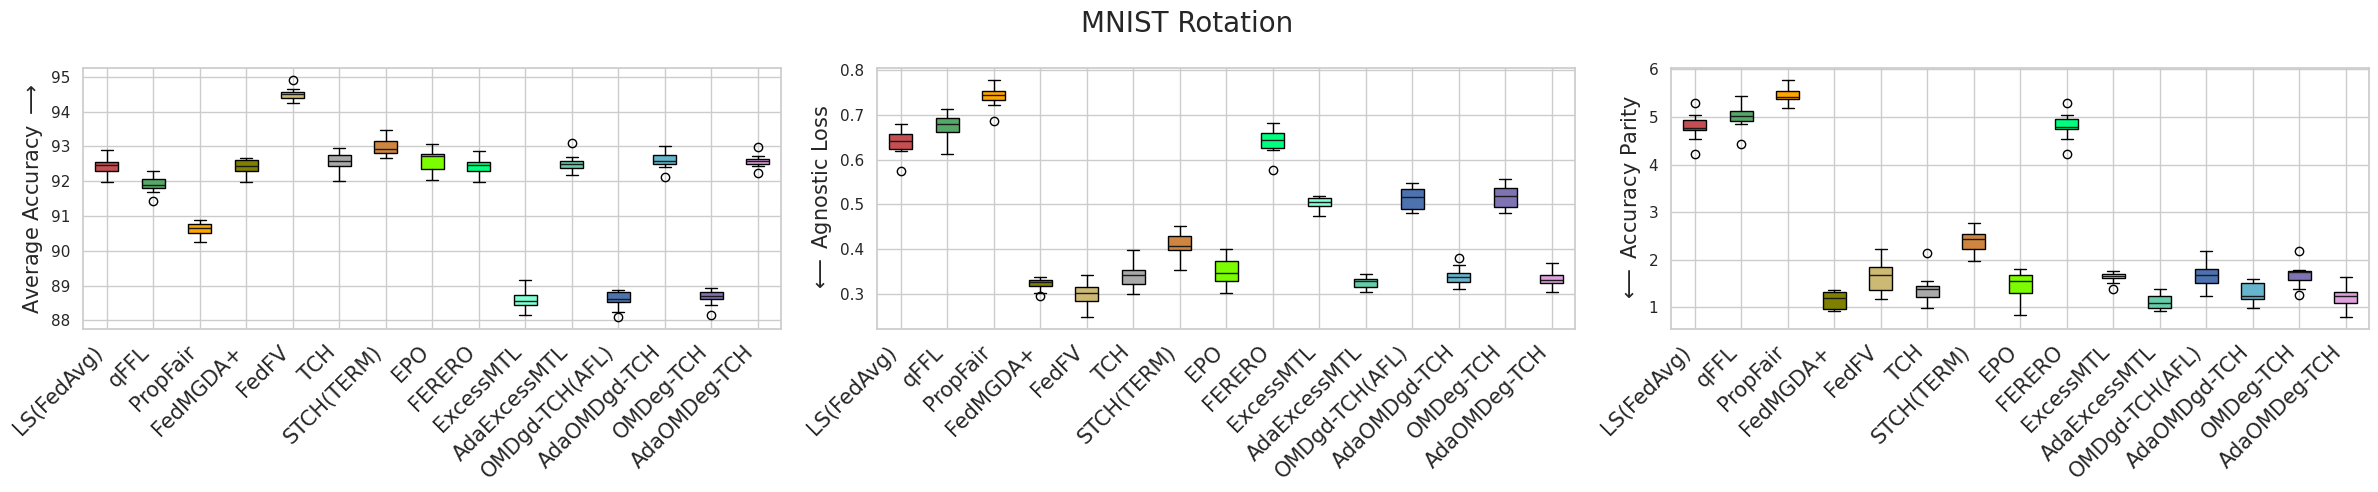

In [12]:
plot_chart('MNIST', 'rotation', seeds, methods)

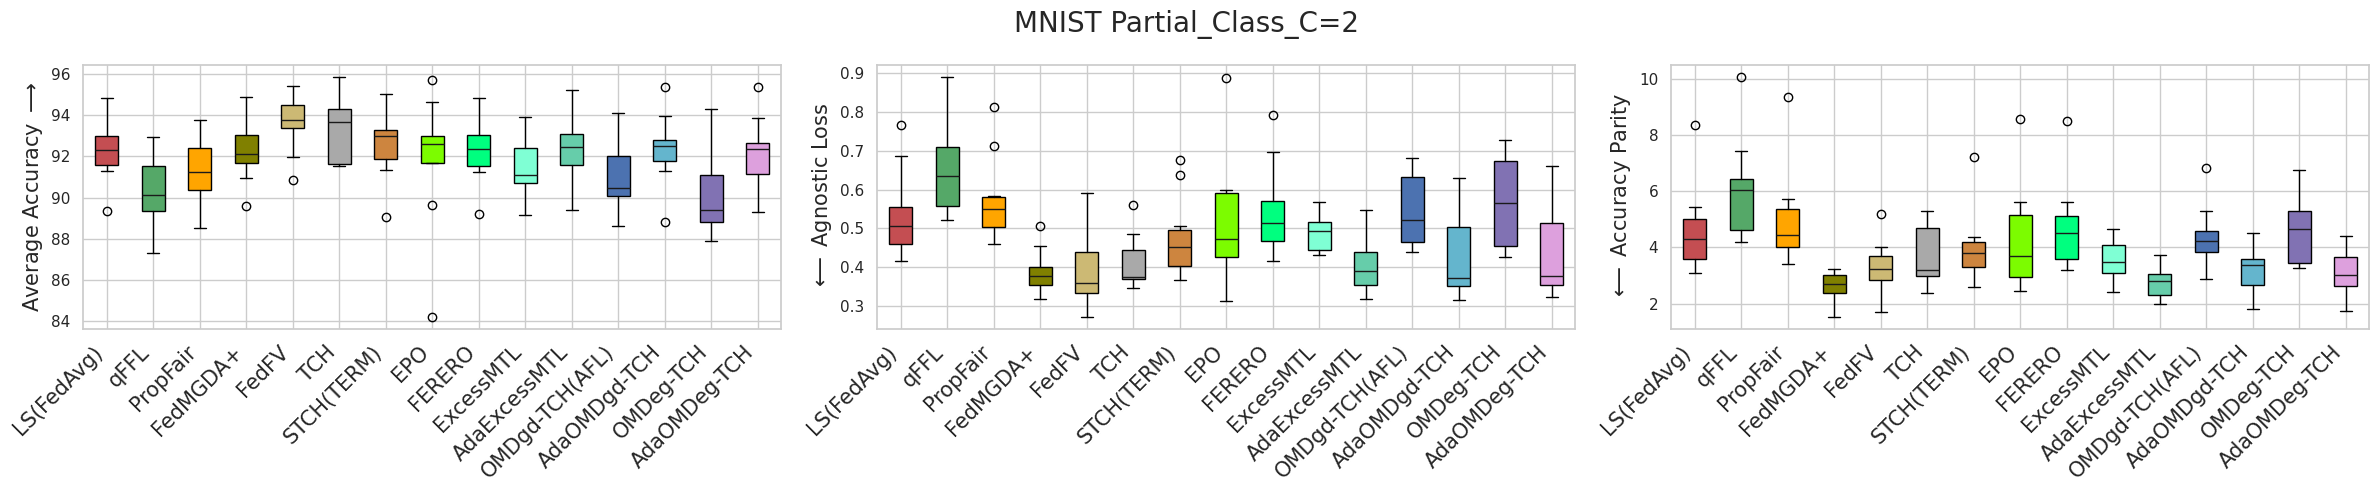

In [13]:
plot_chart('MNIST', 'partial_class_ni2', seeds, methods)

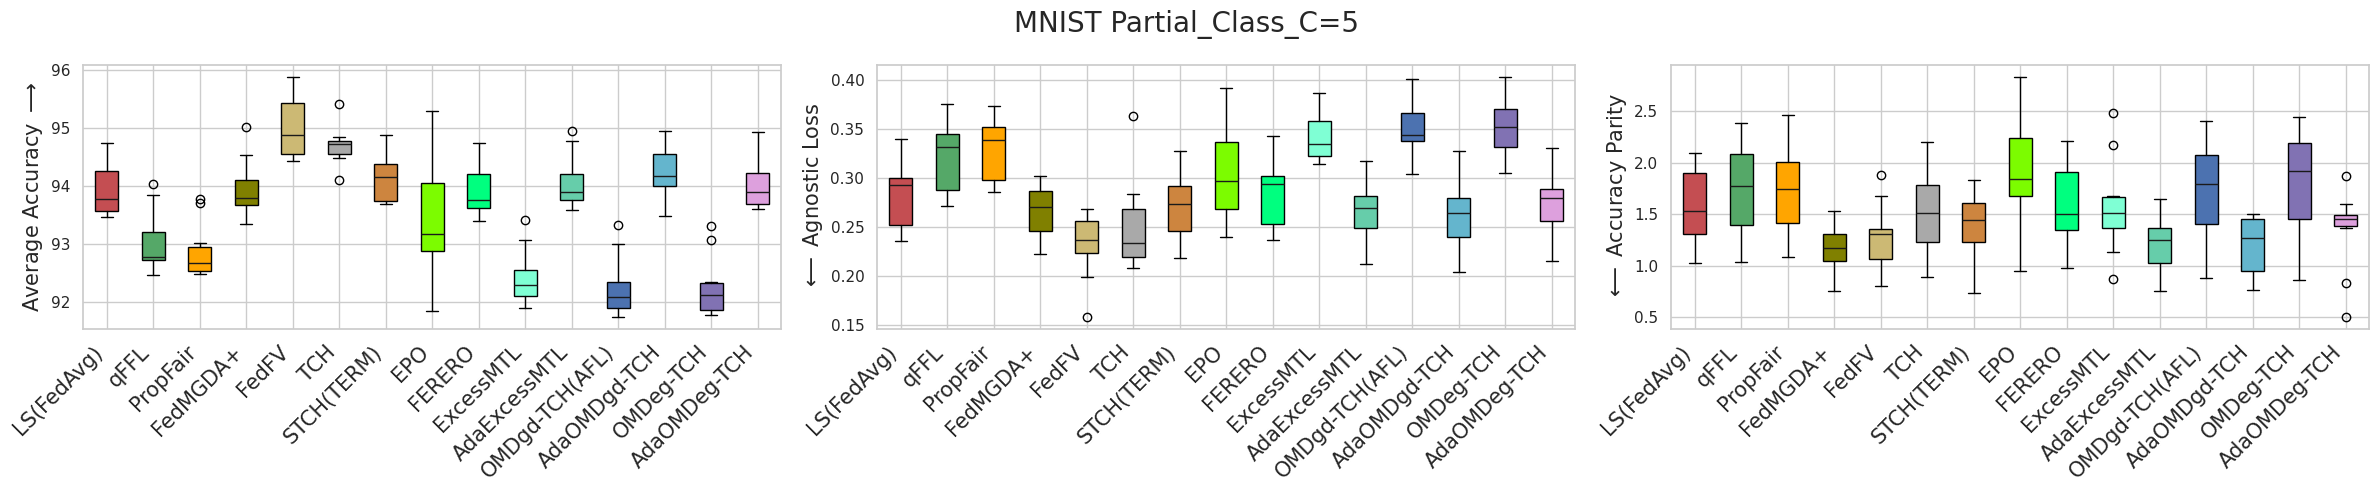

In [14]:
plot_chart('MNIST', 'partial_class_ni5', seeds, methods, ylimmin=90, ylimmax=98)

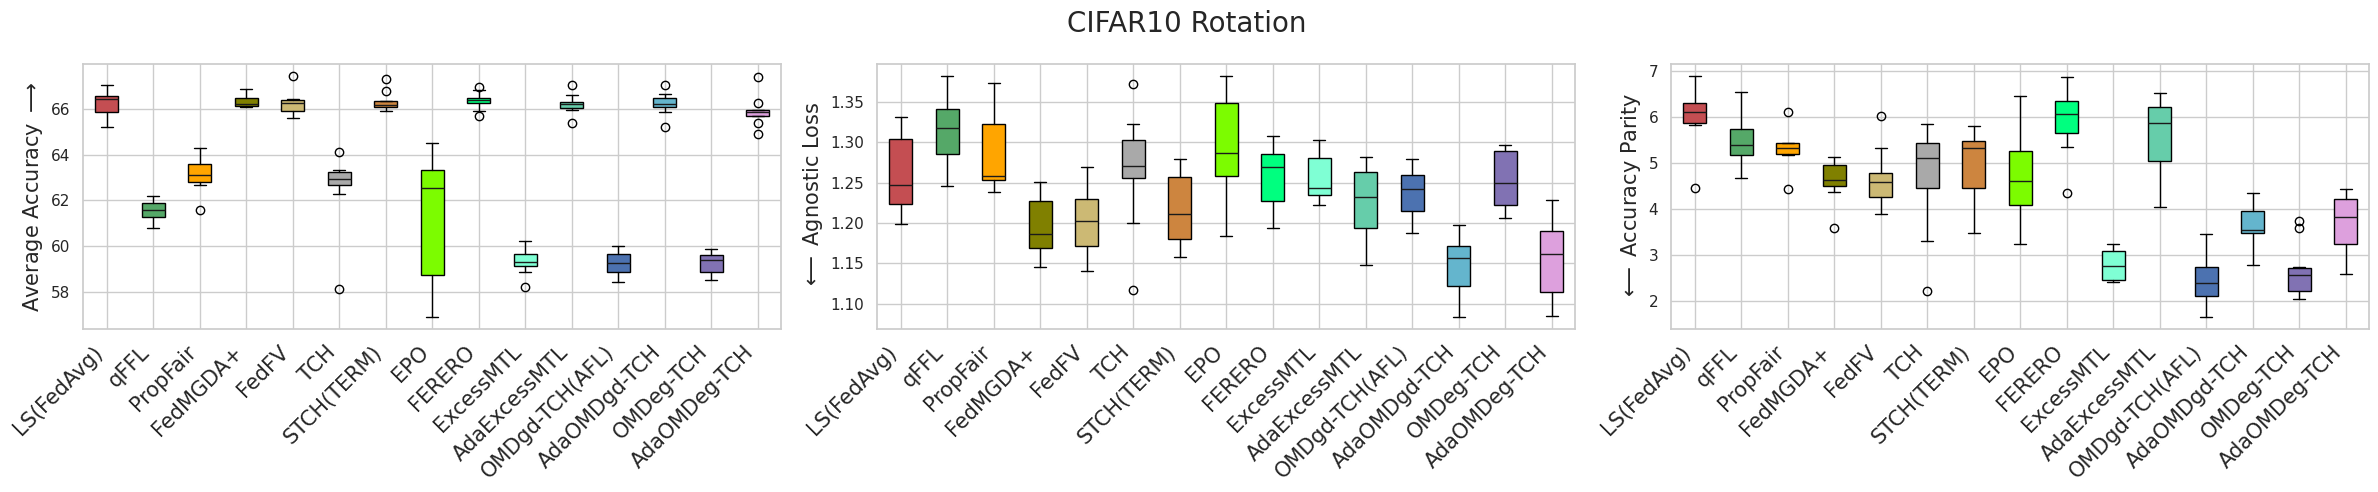

In [15]:
plot_chart('CIFAR10', 'rotation', seeds, methods)

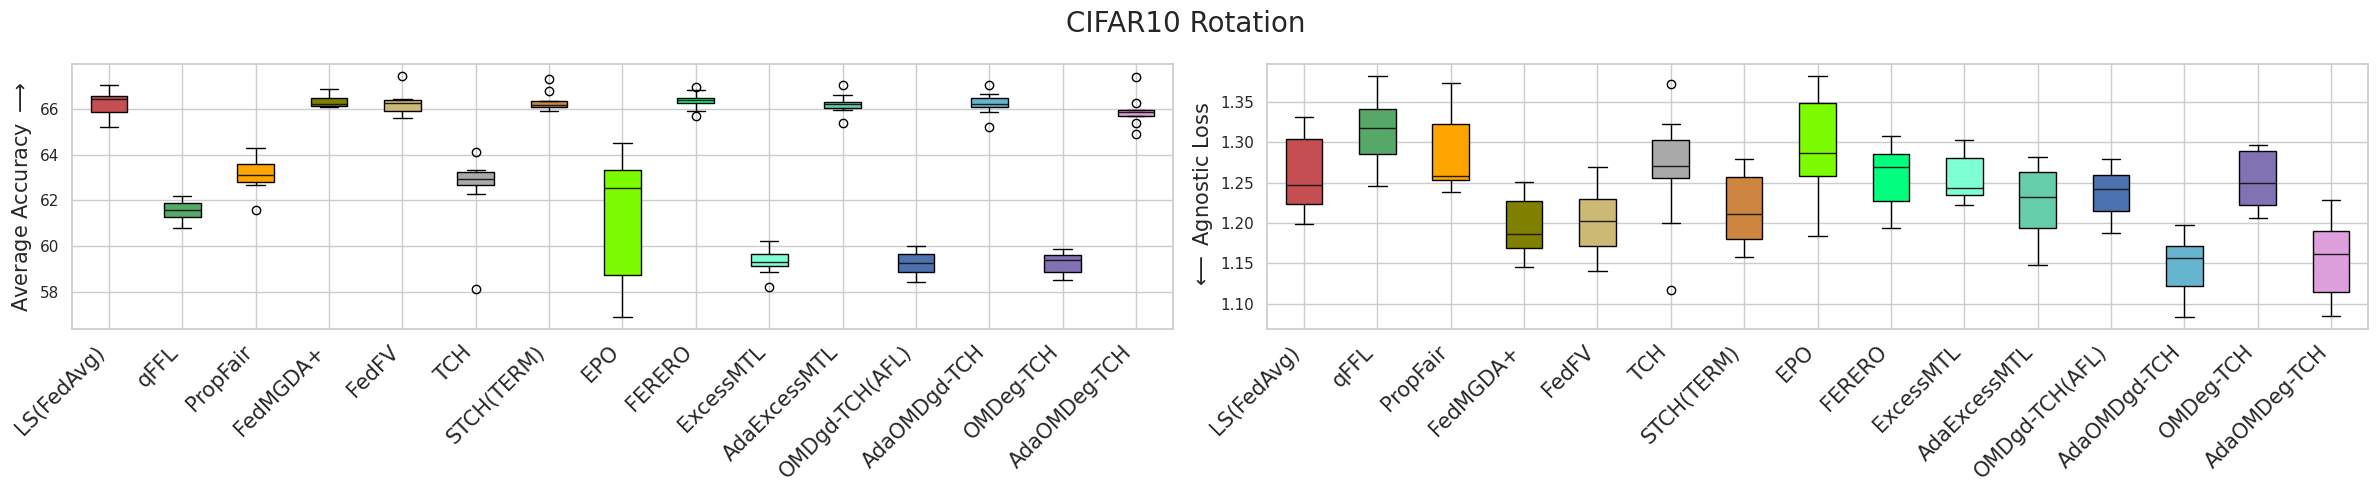

In [27]:
plot_chart('CIFAR10', 'rotation', seeds, methods)

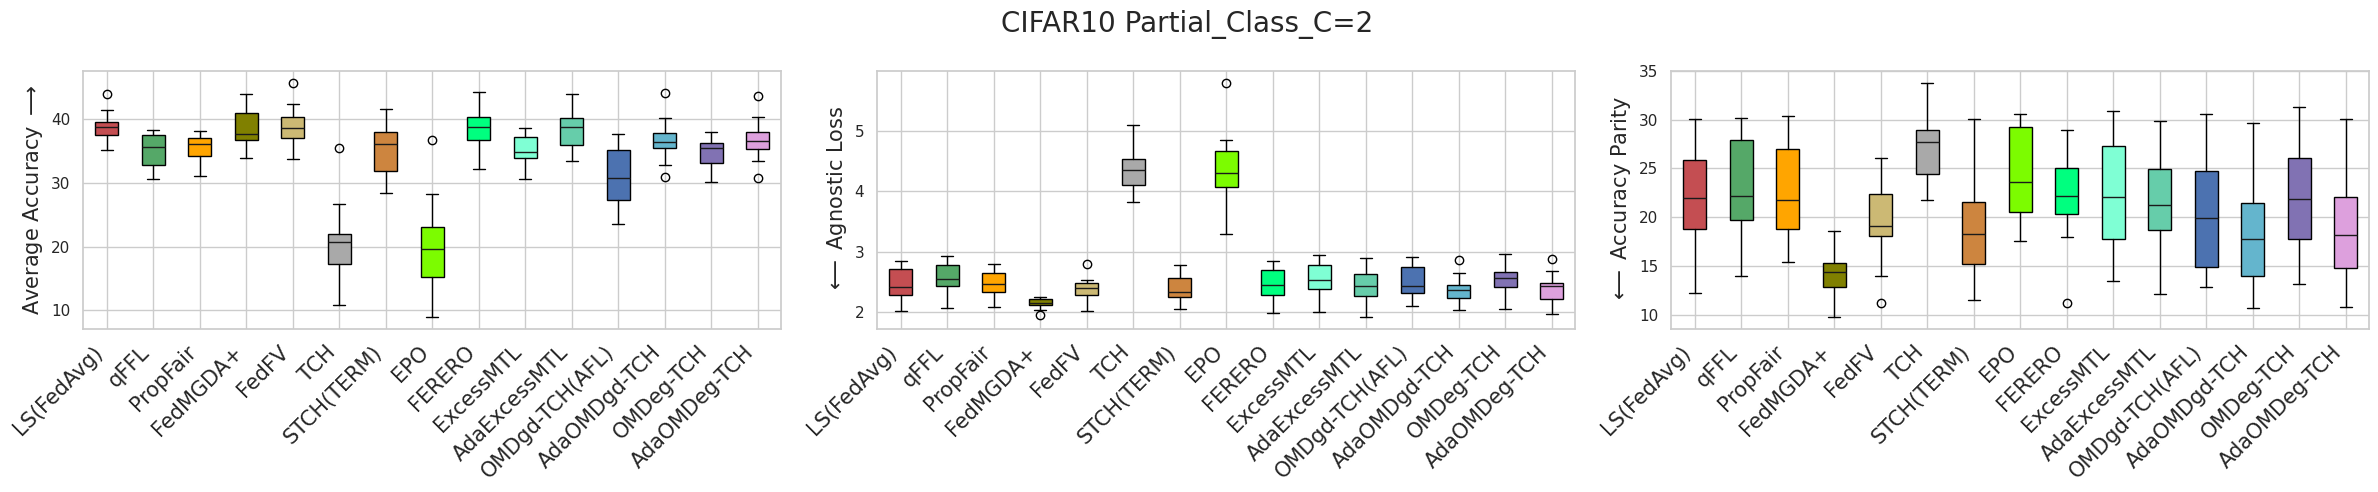

In [16]:
plot_chart('CIFAR10', 'partial_class_ni2', seeds, methods)

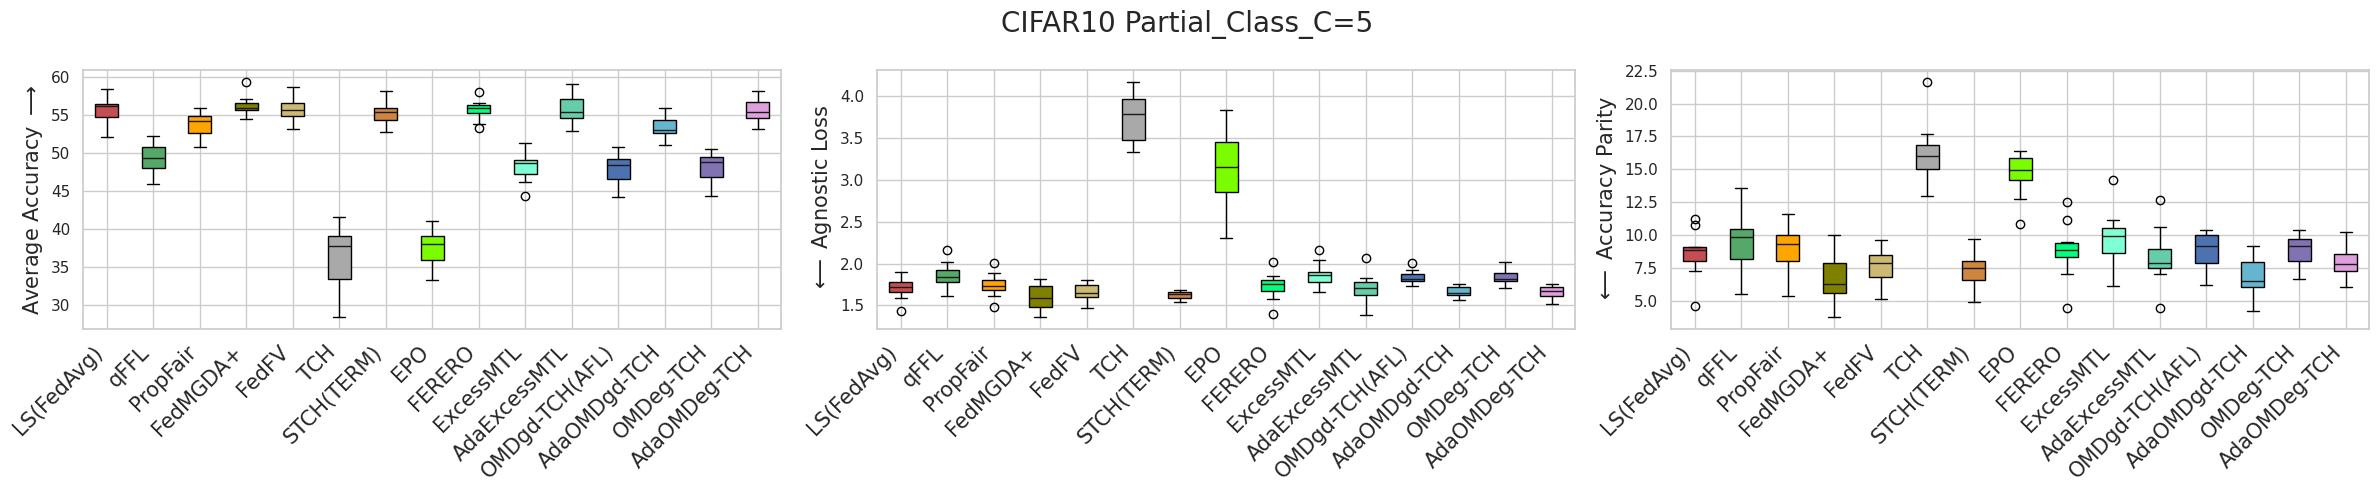

In [17]:
plot_chart('CIFAR10', 'partial_class_ni5', seeds, methods)